# Global Macroeconomic Indicators Analysis (2000–2023)

## Analytical Problem
This project investigates how key macroeconomic indicators — GDP growth, inflation, 
and exchange rates — have evolved across five major economies: the United States, 
China, the United Kingdom, Germany, and Japan, from 2000 to 2023.

## Target Audience
Economics and finance students, and general readers interested in understanding 
long-term global economic trends.

## Data Source
World Bank Open Data API, accessed via `wbdata` library.  
Access date: April 2026

In [1]:
import os
os.makedirs('figures', exist_ok=True)

# Install required libraries (run once)
# !pip install wbdata pandas matplotlib seaborn

import wbdata
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Define countries and indicators to retrieve
countries = ['US', 'CN', 'GB', 'DE', 'JP']
country_names = {'US': 'United States', 'CN': 'China', 'GB': 'United Kingdom',
                 'DE': 'Germany', 'JP': 'Japan'}

indicators = {
    'NY.GDP.MKTP.KD.ZG': 'GDP_Growth',
    'FP.CPI.TOTL.ZG': 'Inflation',
    'PA.NUS.FCRF': 'Exchange_Rate'
}

# Fetch data from World Bank API
df_raw = wbdata.get_dataframe(indicators, country=countries)

# Reset index and rename
df_raw = df_raw.reset_index()
df_raw.columns = ['Country', 'Year'] + list(indicators.values())

# Convert Year to integer
df_raw['Year'] = pd.to_numeric(df_raw['Year'], errors='coerce').astype('Int64')

# Map country codes to full names
df_raw['Country'] = df_raw['Country'].map(
    {v: v for k, v in country_names.items()}  # wbdata returns full names
)

print(f"Raw data shape: {df_raw.shape}")
df_raw.head(10)

Raw data shape: (330, 5)


,Country,Year,GDP_Growth,Inflation,Exchange_Rate
0,China,2025,NaN,NaN,NaN
1,China,2024,4.977357,0.218129,7.197491
2,China,2023,5.414843,0.234837,7.083998
3,China,2022,3.134189,1.973576,6.737158
4,China,2021,8.570085,0.981015,6.448975
5,China,2020,2.340188,2.419422,6.900767
6,China,2019,6.068502,2.899234,6.908385
7,China,2018,6.756718,2.074790,6.615957
8,China,2017,6.891266,1.593136,6.758755
9,China,2016,6.775556,2.000002,6.644478


In [3]:
# Filter to 2000–2023
df = df_raw[(df_raw['Year'] >= 2000) & (df_raw['Year'] <= 2023)].copy()

# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows where all three indicators are missing
df.dropna(subset=['GDP_Growth', 'Inflation'], how='all', inplace=True)

# Sort for readability
df.sort_values(['Country', 'Year'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nCleaned data shape: {df.shape}")
print("\nCountries included:", df['Country'].unique())
df.describe().round(2)

Missing values per column:
Country          0
Year             0
GDP_Growth       0
Inflation        0
Exchange_Rate    0
dtype: int64

Cleaned data shape: (120, 5)

Countries included: <StringArray>
['China', 'Germany', 'Japan', 'United Kingdom', 'United States']
Length: 5, dtype: str


,Year,GDP_Growth,Inflation,Exchange_Rate
count,120.0,120.00,120.00,120.00
mean,2011.5,2.83,1.86,23.77
std,6.95,3.74,1.75,43.44
min,2000.0,-10.05,-1.35,0.50
25%,2005.75,1.10,0.78,0.79
50%,2011.5,2.24,1.63,1.00
75%,2017.25,3.88,2.56,8.03
max,2023.0,14.15,8.00,140.49


## Analysis Overview

We will conduct three layers of analysis:
1. **Trend Analysis** — Line plots of GDP growth and inflation over time per country
2. **Comparative Statistics** — Summary statistics and heatmap of average values
3. **Correlation Analysis** — Relationship between GDP growth and inflation across countries
4. **Crisis Event Annotation** — Highlighting 2008 Financial Crisis and COVID-19 (2020)

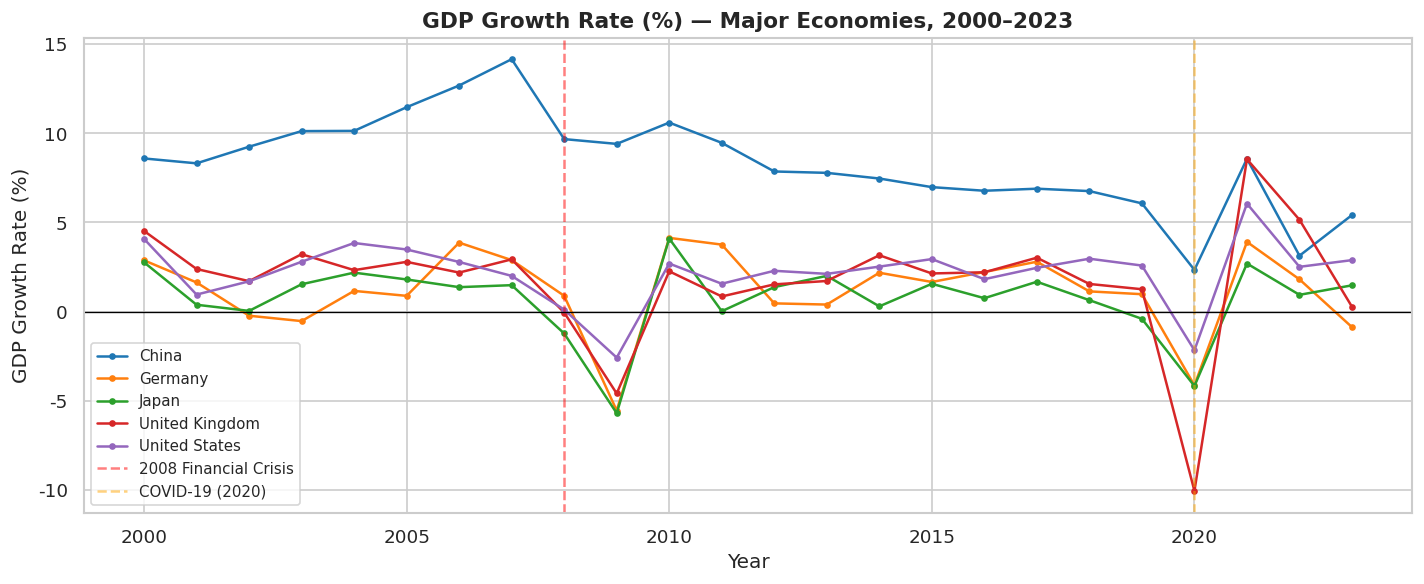

Figure saved.


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

for country in df['Country'].unique():
    data = df[df['Country'] == country]
    ax.plot(data['Year'], data['GDP_Growth'], marker='o', markersize=3, label=country)

# Annotate key events
ax.axvline(x=2008, color='red', linestyle='--', alpha=0.5, label='2008 Financial Crisis')
ax.axvline(x=2020, color='orange', linestyle='--', alpha=0.5, label='COVID-19 (2020)')
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_title('GDP Growth Rate (%) — Major Economies, 2000–2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('GDP Growth Rate (%)')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('figures/gdp_growth_trend.png', bbox_inches='tight')
plt.show()
print("Figure saved.")

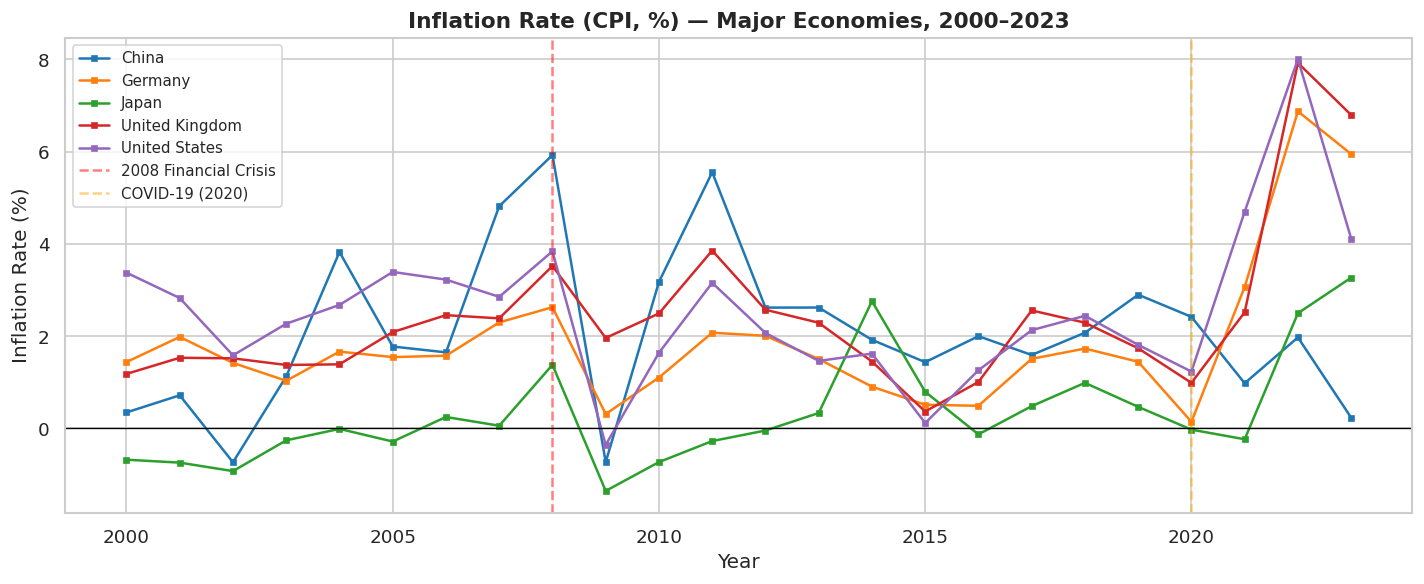

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for country in df['Country'].unique():
    data = df[df['Country'] == country]
    ax.plot(data['Year'], data['Inflation'], marker='s', markersize=3, label=country)

ax.axvline(x=2008, color='red', linestyle='--', alpha=0.5, label='2008 Financial Crisis')
ax.axvline(x=2020, color='orange', linestyle='--', alpha=0.5, label='COVID-19 (2020)')
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_title('Inflation Rate (CPI, %) — Major Economies, 2000–2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('figures/inflation_trend.png', bbox_inches='tight')
plt.show()

Summary Statistics:
                Avg GDP Growth (%)  Avg Inflation (%)
Country                                              
China                         8.33               2.09
Germany                       1.18               1.88
Japan                         0.73               0.32
United Kingdom                1.71               2.43
United States                 2.19               2.56


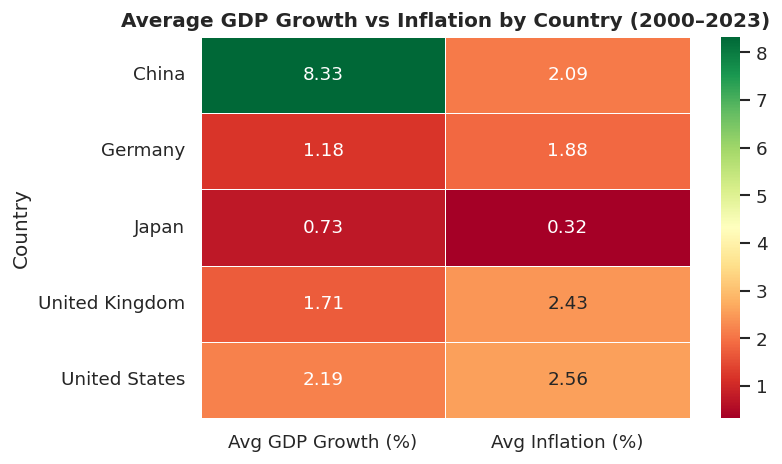

In [6]:
# Compute average GDP growth and inflation per country
summary = df.groupby('Country')[['GDP_Growth', 'Inflation']].mean().round(2)
summary.columns = ['Avg GDP Growth (%)', 'Avg Inflation (%)']

print("Summary Statistics:")
print(summary)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(summary, annot=True, fmt=".2f", cmap='RdYlGn', linewidths=0.5, ax=ax)
ax.set_title('Average GDP Growth vs Inflation by Country (2000–2023)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/heatmap_summary.png', bbox_inches='tight')
plt.show()

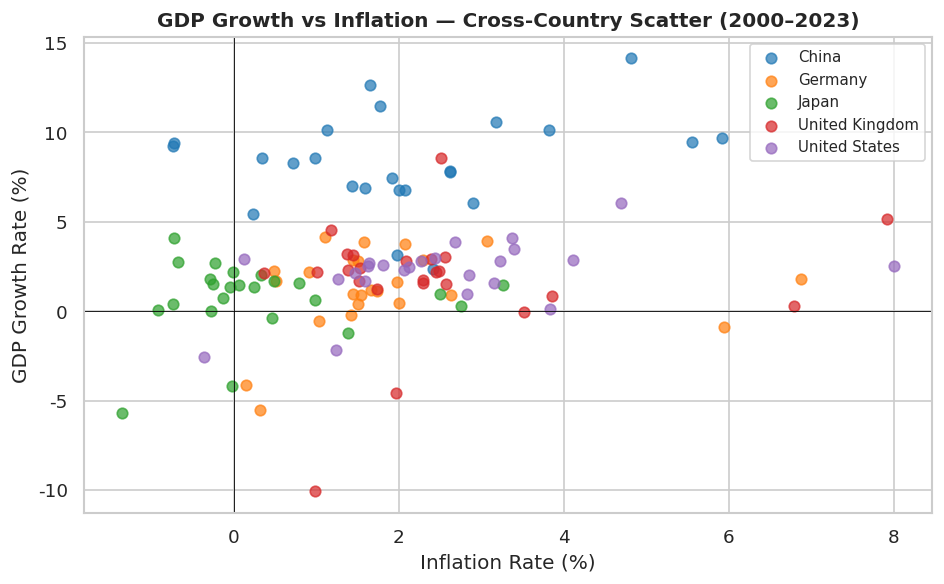

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for country in df['Country'].unique():
    data = df[df['Country'] == country].dropna(subset=['GDP_Growth', 'Inflation'])
    ax.scatter(data['Inflation'], data['GDP_Growth'], label=country, alpha=0.7, s=40)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('GDP Growth vs Inflation — Cross-Country Scatter (2000–2023)', fontweight='bold')
ax.set_xlabel('Inflation Rate (%)')
ax.set_ylabel('GDP Growth Rate (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/scatter_gdp_inflation.png', bbox_inches='tight')
plt.show()

## Key Insights

1. **China consistently leads in GDP growth**, averaging above 7% across the period, 
   though growth has moderated since 2010 as the economy matures.

2. **The 2008 Financial Crisis caused a sharp, synchronised GDP contraction** across 
   all five economies, with Germany and Japan experiencing the steepest declines.

3. **COVID-19 in 2020 triggered the most severe simultaneous downturn** in the 
   dataset, with all economies recording negative growth.

4. **Post-2021 inflation surge** is clearly visible across all countries, likely 
   driven by supply chain disruptions and fiscal stimulus following the pandemic.

5. **Germany and the UK show the highest post-2021 inflation**, reflecting 
   energy price dependence and structural vulnerabilities.

6. **The US demonstrates the most rapid inflation recovery**, consistent with 
   aggressive Federal Reserve rate hikes from 2022.

7. **No strong universal correlation exists between GDP growth and inflation** 
   across all countries, suggesting country-specific structural factors dominate.

In [8]:
# Compute Pearson correlation between GDP growth and inflation per country
print("Pearson Correlation: GDP Growth vs Inflation\n")
for country in df['Country'].unique():
    data = df[df['Country'] == country].dropna(subset=['GDP_Growth', 'Inflation'])
    corr = data['GDP_Growth'].corr(data['Inflation'])
    print(f"  {country}: r = {corr:.3f}")

Pearson Correlation: GDP Growth vs Inflation

  China: r = 0.220
  Germany: r = 0.164
  Japan: r = 0.094
  United Kingdom: r = 0.155
  United States: r = 0.412


## Limitations

- **Data gaps**: Some observations for certain years may be missing in the World Bank 
  database, particularly for exchange rates.
- **CPI as inflation proxy**: CPI may not fully capture inflation experienced 
  by businesses (PPI is an alternative).
- **Exchange rate interpretation**: Official exchange rates may not reflect 
  purchasing power or market dynamics in all cases.
- **No causal inference**: This analysis is descriptive; causality between 
  variables is not established.
- **Five-country scope**: Findings cannot be generalised to all global economies.